In [1]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate
from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
import matplotlib.pyplot as plt
import matplotlib.ticker as tck # Import the ticker module
import seaborn as sns



In [2]:
# Ticker
symbols = ["LINK"]
interval = "4h"

# Time Range

end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = end - pd.Timedelta(days=30 * 6)
# start = pd.to_datetime("2023-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 3
adx_threshold = 25
ce_high_length = 22  # look back length

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# portfolio
# init_cash = 1000

#
k = KrakenHistoricalData()
s = Signals()
k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
# df_multi = k.get_ohlcv_df(symbols, interval=interval)

print(df_multi.head())

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.head())

                              LINK                                            \
                              open     high      low    close         volume   
2023-01-01 00:00:00+00:00  5.56267  5.56426  5.50984  5.53086  323182.887062   
2023-01-01 04:00:00+00:00  5.52101  5.55949  5.50612  5.50612  542641.986225   
2023-01-01 08:00:00+00:00  5.50854  5.53885  5.50854  5.50947  449969.955399   
2023-01-01 12:00:00+00:00  5.50978  5.58239  5.50968  5.57389  195536.824812   
2023-01-01 16:00:00+00:00  5.56977  5.59756  5.55310  5.59482  479285.437429   

                                              
                          trades  base quote  
2023-01-01 00:00:00+00:00     78  LINK   USD  
2023-01-01 04:00:00+00:00    147  LINK   USD  
2023-01-01 08:00:00+00:00     88  LINK   USD  
2023-01-01 12:00:00+00:00    133  LINK   USD  
2023-01-01 16:00:00+00:00    196  LINK   USD  

MultiIndex Removed
                               open      high       low     close  \
2025-04-03 00:00:00+0

In [3]:
# Signals
signals = df.copy()
# moving average
# ma = pta.ohlc4(df['open'],df['high'],df['low'],df['close'])
ma = pta.zlma(df['close'], 10)

# Calculate technical indicators
signals['rsi'] = pta.rsi(df['close'])

# adx > 25 strong trend
adx = pta.adx(df['high'], df['low'], df['close'])

# Entry: SAR Signal
psar = pta.psar(df['high'],
                df['low'],
                close=df['close'])
print(f"\nSAR:")

signals['sar'] = psar.iloc[:, 0]
# signals['sar_s'] = np.where(signals['sar'] > 0, True, False)

signals['sar_s'] = signals['close'] > signals['sar']

print(signals[['sar', 'sar_s']].tail())  # Entry Signals

print(f"\nADX:")
print(tabulate(adx.tail(), headers="keys", tablefmt="github"))
signals['adx'] = adx.iloc[:, 0]
signals['adx_d'] = adx.iloc[:, 1]
signals['adx_dmp'] = adx.iloc[:, 2]
signals['adx_dmn'] = adx.iloc[:, 3]
signals['adx_s'] = np.where(signals['adx'] > adx_threshold, True, False)
signals['adx_bullish'] = np.where(signals['adx_dmp'] > signals['adx_dmn'], True, False)
signals['adx_s'] = signals['adx_s'] & signals['adx_bullish']

# Exit: Chandlier Exit uses ATR
signals['atr'] = pta.atr(df['high'], df['low'], df['close'])
ce = pta.chandelier_exit(df['high'],
                         df['low'],
                         df['close'],
                         multiplier=atr_multiplier, high_length=ce_high_length)
print(f"\nChandlier_Raw")
print(tabulate(ce.tail(), headers="keys", tablefmt="github"))
signals['ce_l'] = np.where(ce.iloc[:, 2] > 0, ce.iloc[:, 0], np.nan)
signals['ce_sh'] = np.where(ce.iloc[:, 2] < 0, ce.iloc[:, 1], np.nan)
signals['ce_exit'] = np.where(ce.iloc[:, 2] == 1, False, True)
print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].tail(50))

# entry

# Have ADX strength, and sar is a buy and ce is not an exit
entry_series = signals['adx_s'] & signals['sar_s'] & ~signals['ce_exit']
entry_rise = entry_series & (~entry_series.shift(1, fill_value=False))

# eixt
exit_series = signals['ce_exit']

exit_rise = exit_series & (~exit_series.shift(1, fill_value=False))

entry_exit_df = pd.concat([entry_series, entry_rise, exit_series, exit_rise], axis=1)
entry_exit_df.columns = ['entry_series', 'entry_rise', 'exit_series', 'exit_rise']

print(f"\nEntry/Exit Signals:")
print(entry_exit_df.tail(50))



SAR:
                                 sar  sar_s
2025-09-29 08:00:00+00:00  20.454093   True
2025-09-29 12:00:00+00:00  20.529278   True
2025-09-29 16:00:00+00:00  20.599952   True
2025-09-29 20:00:00+00:00  20.691250   True
2025-09-30 00:00:00+00:00  20.812154   True

ADX:
|                           |   ADX_14 |   ADXR_14_2 |   DMP_14 |   DMN_14 |
|---------------------------|----------|-------------|----------|----------|
| 2025-09-29 08:00:00+00:00 |  31.5327 |     33.6465 |  20.57   |  23.6514 |
| 2025-09-29 12:00:00+00:00 |  29.6799 |     31.5511 |  22.8331 |  20.414  |
| 2025-09-29 16:00:00+00:00 |  28.0923 |     29.8125 |  21.5415 |  18.5531 |
| 2025-09-29 20:00:00+00:00 |  27.0769 |     28.3784 |  23.6204 |  17.8637 |
| 2025-09-30 00:00:00+00:00 |  25.3145 |     26.7034 |  21.945  |  20.9152 |

Chandlier_Raw
|                           |   CHDLREXTl_22_22_14_3 |   CHDLREXTs_22_22_14_3 |   CHDLREXTd_22_22_14_3 |
|---------------------------|------------------------|-----------

In [4]:
# filter entries and exits, one for one entry/exit

in_pos = False
filtered_entry = pd.Series(False, index=signals.index)
filtered_exit = pd.Series(False, index=signals.index)

for ts in signals.index:
    if not in_pos and entry_rise.loc[ts]:
        filtered_entry.loc[ts] = True
        in_pos = True
    elif in_pos and exit_rise.loc[ts]:
        filtered_exit.loc[ts] = True
        in_pos = False
    # elif in_pos and exit_series.loc[ts]:
    #     filtered_exit.loc[ts] = True
    #     in_pos = False
# filtered_exit = filtered_entry.shift(-1, fill_value=False)
i_start = 30 * 6
i_end = 60 * 6
entry_concat = pd.concat([entry_series.iloc[i_start:i_end], filtered_entry.iloc[i_start:i_end]], axis=1)
exit_concat = pd.concat([exit_series.iloc[i_start:i_end], filtered_exit.iloc[i_start:i_end]], axis=1)

print(f"\nFiltered Entry/Exit Signals:")
print(tabulate(pd.concat([entry_concat, exit_concat, signals['ce_l']], axis=1).iloc[i_start:i_end],
               headers=["entry", "filtered_entry", "exit", "filtered_exit", "ce_l"], tablefmt="github"))

print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].iloc[i_start:i_end])

print(f"\nExit Prices:")
print(signals['ce_l'].loc[filtered_exit.shift(-1, fill_value=False).values])


Filtered Entry/Exit Signals:
|                           | entry   | filtered_entry   | exit   | filtered_exit   |     ce_l |
|---------------------------|---------|------------------|--------|-----------------|----------|
| 2025-05-03 00:00:00+00:00 | False   | False            | False  | False           |  14.1549 |
| 2025-05-03 04:00:00+00:00 | False   | False            | False  | False           |  14.1809 |
| 2025-05-03 08:00:00+00:00 | False   | False            | False  | False           |  14.2125 |
| 2025-05-03 12:00:00+00:00 | False   | False            | False  | False           |  14.2249 |
| 2025-05-03 16:00:00+00:00 | False   | False            | False  | False           |  14.2274 |
| 2025-05-03 20:00:00+00:00 | False   | False            | False  | False           |  14.2446 |
| 2025-05-04 00:00:00+00:00 | False   | False            | True   | False           | nan      |
| 2025-05-04 04:00:00+00:00 | False   | False            | True   | False           | nan      |


In [5]:
entry_times = list(filtered_entry[filtered_entry].index)
exit_times = list(filtered_exit[filtered_exit].index)

# 2) Pair entries with the next exit after each entry
pairs = []
j = 0
for et in entry_times:
    while j < len(exit_times) and exit_times[j] <= et:
        j += 1
    if j < len(exit_times):
        pairs.append((et, exit_times[j]))
        j += 1

close = signals['close']
exits_price = signals['ce_l'].shift(-1).ffill() * filtered_exit

entries_price = close * filtered_entry
profit = pd.Series(0.0, index=filtered_entry.index)
profit_pct = profit.copy()
for pair in pairs:
    exit_price = exits_price.loc[pair[1]]
    entry_price = entries_price.loc[pair[0]]
    profit.loc[pair[1]] = exit_price - entry_price - (transaction_fee * (exit_price + entry_price))
    profit_pct.loc[pair[1]] = profit.loc[pair[1]] / entry_price

profit_cum = profit.cumsum()
profit[profit == 0.0] = np.nan
profit_pct[profit_pct == 0.0] = np.nan
profit_df = pd.concat([entries_price, exits_price, profit, profit_cum, profit_pct], axis=1)
profit_df.columns = ['Entry_Price', 'Exit_Price', 'Profit', 'Cumulative_Profit', 'Profit_Pct']
wins = (profit_df['Profit'] > 0).sum()
loss = (profit_df['Profit'] < 0).sum()

trading_days = (end - start).days

trading_map = {'4h': 6 * 365, '1h': 24 * 365, '1d': 365}
trading_periods = trading_map.get(interval)

stats = profit_df['Profit'].describe()
stats_pct = profit_df['Profit_Pct'].describe()
sharpe = stats['mean'] / stats['std'] * np.sqrt(trading_periods)
win_rate = wins / (wins + loss)
print(f"\nPerformance  Stats:")
print(f"Trading Days: {trading_days}")
print(f"Average Return: {stats['mean']:,.2f}")
print(f"Std.Dev Return: {stats['std']:,.2f}")
print(f"Average Return %: {stats_pct['mean'] * 100:,.2f}")
print(f"Std.Dev Return %: {stats_pct['std'] * 100:,.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Total Profit: {profit_df['Cumulative_Profit'].iloc[-1]:,.2f}")
print(f"Wins: {wins}")
print(f"Losses: {loss}")
print(f"Win Rate: {win_rate:.2%}")

# print(f"\nLast 200 profit_df:")
# print(tabulate(profit_df.tail(200), headers='keys',
#                tablefmt='github'))
# With DMP >DMN  sharpe Ratio 6.29, 2 years, BTC
# without DMP> DMN Sharpe Ratio 5.41, 2 years, BTC
# with DMP > DMN Sharpe Ratio 2.08, .5 years, BTC
# without DMP> DMN Sharpe Ratio .29, .5 years, BTC


Performance  Stats:
Trading Days: 180
Average Return: 0.35
Std.Dev Return: 1.77
Average Return %: 2.52
Std.Dev Return %: 10.57
Sharpe Ratio: 9.13
Total Profit: 4.84
Wins: 6
Losses: 8
Win Rate: 42.86%


In [6]:
##  Boolean where in position
y1_arr = signals['close'].values
in_position = pd.Series(pd.NA, index=filtered_entry.index, dtype="boolean")
in_position[filtered_entry] = filtered_entry[filtered_entry]
in_position[filtered_exit] = ~filtered_exit[filtered_exit]
in_position.ffill(inplace=True)
y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]

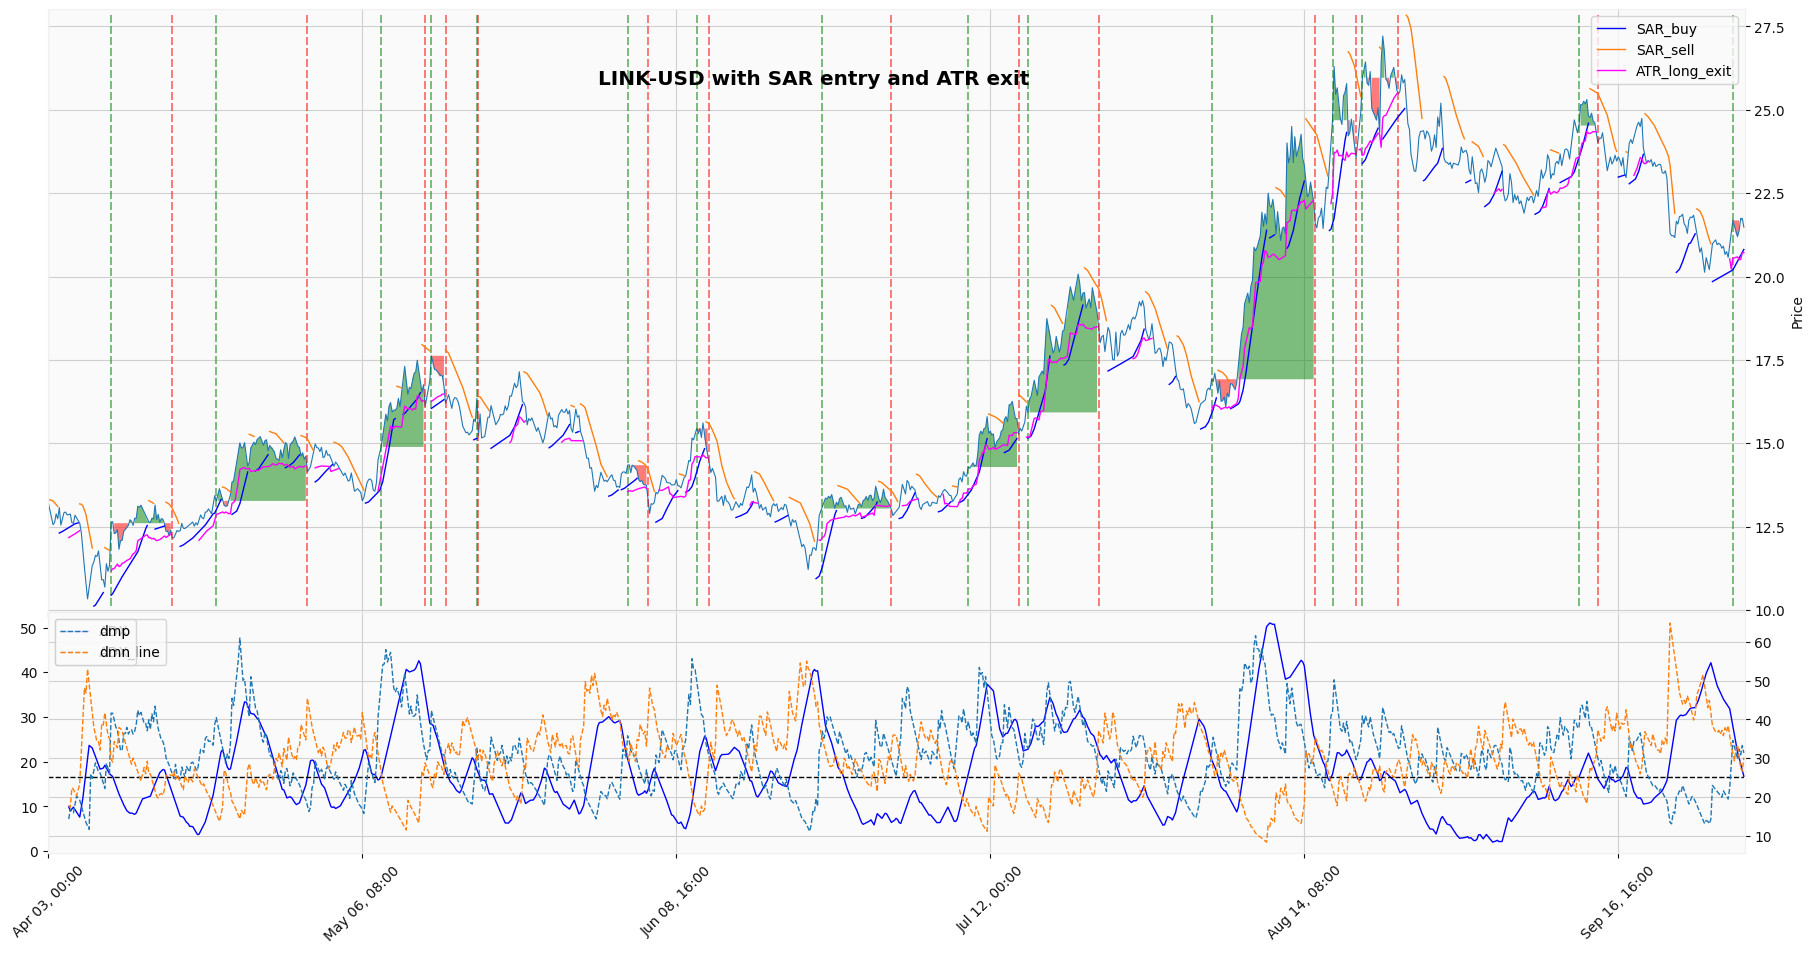

In [7]:
# Combine and color differently
vline_dates = list(filtered_entry[filtered_entry].index) + list(filtered_exit[filtered_exit].index)
vline_colors = (['g'] * filtered_entry.sum()) + (['r'] * filtered_exit.sum())
adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(psar.iloc[:, 0], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(psar.iloc[:, 1], type='line', width=1.0, label='SAR_sell'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),
    # mpf.make_addplot(signals['ce_sh'], type='line', width=1.0, label='ATR_short_exit',
    #                  secondary_y=False),
    mpf.make_addplot(signals['adx'], type='line', color='blue', width=1.0, label='ADX', panel=1),
    mpf.make_addplot(signals['adx_dmp'], type='line', linestyle='--', width=1.0, label='dmp', panel=1),
    mpf.make_addplot(signals['adx_dmn'], type='line', linestyle='--', width=1.0, label='dmn', panel=1),
    mpf.make_addplot(adx_line, type='line', color="black", linestyle='--', width=1.0, label='ADX_line', panel=1),
    # mpf.make_addplot(profit_cum, type='line', width=1.0, label='Profit', panel=2),
    # mpf.make_addplot(zero_line, type='line', color="black", linestyle='--', width=1.0, label='Zero_line', panel=2,
    #                  secondary_y=False),
    # mpf.make_addplot(profit, type='scatter', panel=3),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=False,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 9),
    figscale=1.7,
    tight_layout=True,
    title=f"{symbols[0]}-USD with SAR entry and ATR exit",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,
)


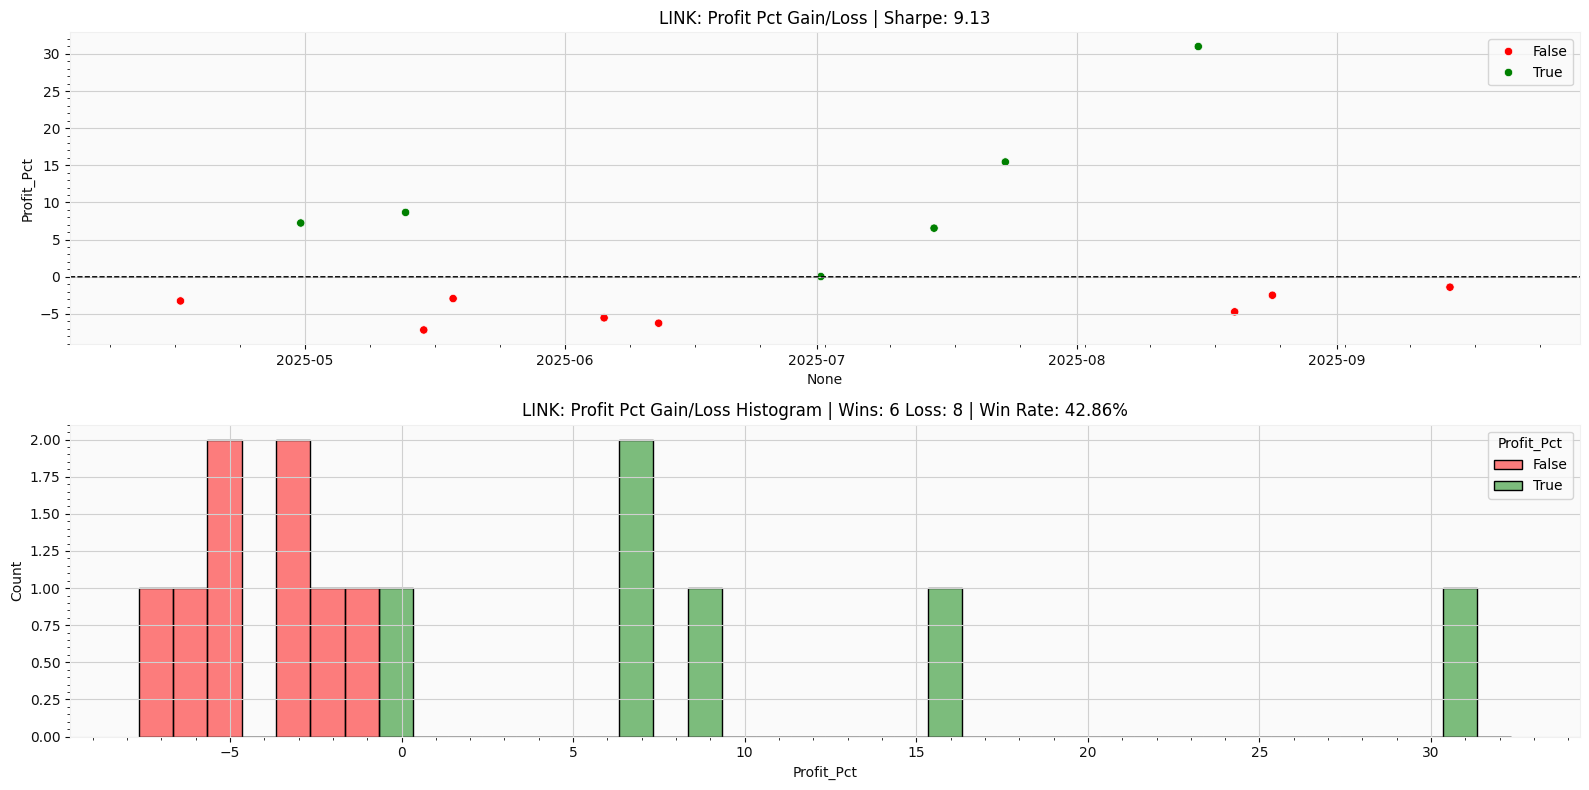

In [8]:


fig,axes = plt.subplots(2,1,figsize=(16, 8))  # wider figure


sns.scatterplot(data=profit_df, x=profit_df.index, y=profit_df['Profit_Pct'] * 100, hue=profit_df['Profit_Pct'] > 0,
                palette={True: 'green', False: 'red'}, ax=axes[0])
sns.lineplot(zero_line, linestyle='--', color="black", linewidth=1.0,ax=axes[0])
axes[0].set_title(f"{symbols[0]}: Profit Pct Gain/Loss | Sharpe: {sharpe:.2f}")
axes[0].minorticks_on()

axes[0].set_xlim(start, end)

# fig3 = plt.figure(figsize=(16, 4))  # wider figure
sns.histplot(profit_df,
            x=profit_df['Profit_Pct'] * 100,
            hue=profit_df['Profit_Pct'] > 0,
            discrete=True,
            palette={True: 'green', False: 'red'},
            # height=4,
            # aspect=4,
            ax=axes[1]
            )
axes[1].set_title(f"{symbols[0]}: Profit Pct Gain/Loss Histogram | Wins: {wins} Loss: {loss} | Win Rate: {win_rate:.2%}")
axes[1].minorticks_on()
plt.tight_layout()
plt.show()